# Analytics Engineering — Group 09 · CrediTrust Capital
**Role:** Analytics Engineer (AE) · **Dataset:** UCI Statlog German Credit · **Course:** BCDA 5P126

**Goal:** turn the model's default probabilities into credit decisions, and choose the decision threshold that minimises business cost.

**Business rule (from the brief):** approving a defaulter (Type II error) costs **5×** rejecting a good applicant (Type I error).

**Conventions used everywhere in this notebook**
| Item | Meaning |
|---|---|
| `y_true = 1` | applicant DEFAULTED (raw dataset class 2 = bad) |
| `y_true = 0` | good applicant (raw class 1) |
| `p_default` | model probability of default = P(class 2) |
| `p_default >= threshold` | **REJECT / manual review**; otherwise **APPROVE** |



In [9]:
import os

for f in os.listdir("src"):
    if f.startswith("analytics_engine") and f != "analytics_engine.py":
        print("Renaming:", repr(f))
        os.rename(f"src/{f}", "src/analytics_engine.py")

print("src/ now:", os.listdir("src"))

Renaming: 'analytics_engine .py'
src/ now: ['preprocessing.pkl', 'model.py', 'preprocessing.py', 'predict.py', 'export_predictions.py', 'Final_model (1).pkl', 'analytics_engine.py']


In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))
import analytics_engine as ae

cfg = ae.CostConfig()
print(f"Type I cost = {cfg.c_fp}, Type II cost = {cfg.c_fn}, LGD assumption = {cfg.lgd}")


Type I cost = 1.0, Type II cost = 5.0, LGD assumption = 0.6


## 1. Generate predictions


In [13]:
PROJECT = Path.cwd()
PROC = PROJECT / "data" / "processed"
import subprocess

r = subprocess.run([sys.executable, str(PROJECT / "src" / "export_predictions.py")],
                   capture_output=True, text=True, cwd=PROJECT)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)
    raise RuntimeError("export_predictions.py failed - read the error above")

Model classes: [np.int64(1), np.int64(2)] -> P(default) = predict_proba column 1
OOF (train)  rows= 800  default rate=0.300  mean P(default)=0.284
TEST         rows= 200  default rate=0.300  mean P(default)=0.311
Saved oof_predictions.csv and test_predictions.csv to /content/ML-Final-Lab-Group-09/data/processed



## 2. Load and sanity-check the prediction files

In [14]:
oof  = pd.read_csv(PROC / "oof_predictions.csv")
test = pd.read_csv(PROC / "test_predictions.csv")

for name, d in (("OOF (train, used to tune)", oof), ("TEST (used to report)", test)):
    assert set(d["y_true"].unique()) <= {0, 1}, "y_true must be 0/1"
    assert d["p_default"].between(0, 1).all(), "p_default must be in [0, 1]"
    print(f"{name:26s} rows={len(d):4d}  default rate={d['y_true'].mean():.1%}  "
          f"mean p_default={d['p_default'].mean():.3f}")
test.head()

OOF (train, used to tune)  rows= 800  default rate=30.0%  mean p_default=0.284
TEST (used to report)      rows= 200  default rate=30.0%  mean p_default=0.311


,y_true,p_default,credit_amount,duration
0,0,0.214108,1913.0,18.0
1,0,0.081980,1860.0,12.0
2,1,0.745649,1024.0,24.0
3,0,0.425209,3104.0,18.0
4,1,0.185593,2520.0,27.0


## 3. Confusion cost-matrix model

The **cost-optimal threshold** comes from comparing the two expected costs for an applicant with default probability *p*:

* approve → expected cost `p × c_fn`
* reject → expected cost `(1 − p) × c_fp`

Reject when `(1 − p)·c_fp < p·c_fn`, i.e. `p > c_fp / (c_fp + c_fn) = 1/6 ≈ 0.167`.

In [15]:
display(ae.cost_matrix(cfg))
print(f"Theoretical cost-optimal threshold = {cfg.theoretical_threshold:.3f}")

,Decision APPROVE,Decision REJECT
Actual GOOD (0),0.0,1.0
Actual DEFAULT (1),5.0,0.0


Theoretical cost-optimal threshold = 0.167


## 4. Reference strategies on the test set


In [16]:
n = len(test)
strategies = {
    "Approve everyone (no model)": np.zeros(n, dtype=int),
    "Reject everyone":             np.ones(n, dtype=int),
    "Model, default threshold 0.50": (test["p_default"] >= 0.50).astype(int),
}
ref = pd.DataFrame({k: ae.cost_metrics(test["y_true"], v, cfg) for k, v in strategies.items()}).T
ref[["TP", "FP", "FN", "TN", "total_cost", "recall_default", "approval_rate", "cost_weighted_f1"]]

,TP,FP,FN,TN,total_cost,recall_default,approval_rate,cost_weighted_f1
Approve everyone (no model),0.0,0.0,60.0,140.0,300.0,0.0,1.000,0.0000
Reject everyone,60.0,140.0,0.0,0.0,140.0,1.0,0.000,0.4615
"Model, default threshold 0.50",30.0,21.0,30.0,119.0,171.0,0.5,0.745,0.2597


## 5. Threshold tuning — on out-of-fold data only
Every threshold from 0.05 to 0.95 is evaluated on the OOF predictions. The chosen threshold is the one with the **lowest total cost** (ties broken toward higher recall).

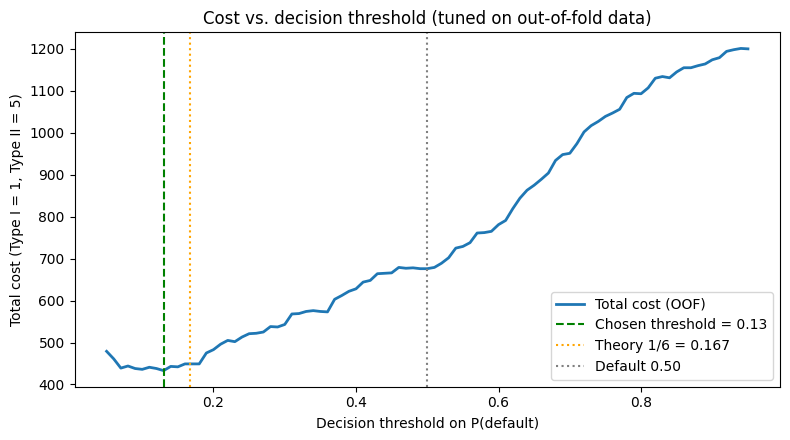

Chosen threshold: 0.13


,threshold,TP,FP,FN,TN,precision_default,recall_default,cost_weighted_f1,total_cost,cost_per_applicant,approval_rate
0,0.05,230,429,10,131,0.3490,0.9583,0.4899,479.0,0.5988,0.1762
1,0.06,228,401,12,159,0.3625,0.9500,0.4973,461.0,0.5763,0.2137
2,0.07,226,369,14,191,0.3798,0.9417,0.5073,439.0,0.5487,0.2562
3,0.08,221,349,19,211,0.3877,0.9208,0.4989,444.0,0.5550,0.2875
4,0.09,220,338,20,222,0.3943,0.9167,0.5011,438.0,0.5475,0.3025
5,0.10,218,326,22,234,0.4007,0.9083,0.5000,436.0,0.5450,0.3200
6,0.11,213,306,27,254,0.4104,0.8875,0.4913,441.0,0.5513,0.3513
7,0.12,211,293,29,267,0.4187,0.8792,0.4907,438.0,0.5475,0.3700
8,0.13,210,283,30,277,0.4260,0.8750,0.4924,433.0,0.5413,0.3837
9,0.14,207,278,33,282,0.4268,0.8625,0.4831,443.0,0.5537,0.3937


In [17]:
sweep = ae.threshold_sweep(oof["y_true"], oof["p_default"], cfg)
t_star = ae.best_threshold(sweep)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep["threshold"], sweep["total_cost"], lw=2, label="Total cost (OOF)")
ax.axvline(t_star, color="green", ls="--", label=f"Chosen threshold = {t_star:.2f}")
ax.axvline(cfg.theoretical_threshold, color="orange", ls=":", label=f"Theory 1/6 = {cfg.theoretical_threshold:.3f}")
ax.axvline(0.5, color="grey", ls=":", label="Default 0.50")
ax.set_xlabel("Decision threshold on P(default)")
ax.set_ylabel("Total cost (Type I = 1, Type II = 5)")
ax.set_title("Cost vs. decision threshold (tuned on out-of-fold data)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Chosen threshold: {t_star:.2f}")
sweep.loc[sweep["threshold"].between(t_star - 0.10, t_star + 0.10)]

## 6. Testing on the held-out test set

Taking the threshold picked in the last step and and then applying it to the test set (which is not  touched until now). We compare it against just using 0.50 as the cutoff, and against not using a model at all.

In [19]:
pred_star = (test["p_default"] >= t_star).astype(int)
res_star  = ae.cost_metrics(test["y_true"], pred_star, cfg)
res_050   = ae.cost_metrics(test["y_true"], (test["p_default"] >= 0.5).astype(int), cfg)

final_cmp = pd.DataFrame({
    f"Tuned threshold ({t_star:.2f})": res_star,
    "Default threshold (0.50)": res_050,
}).T[["TP", "FP", "FN", "TN", "total_cost", "cost_per_applicant",
      "precision_default", "recall_default", "cost_weighted_f1", "approval_rate"]]
display(final_cmp)

cm = pd.DataFrame(
    [[res_star["TN"], res_star["FP"]], [res_star["FN"], res_star["TP"]]],
    index=["Actual GOOD", "Actual DEFAULT"], columns=["Decision APPROVE", "Decision REJECT"])
print("Confusion matrix at the tuned threshold (test set):")
display(cm)

print(f"Cost saved vs. approving everyone: {res_star['cost_saved_vs_approve_all']:.0f} cost units")
print(f"Cost saved vs. default 0.50      : {res_050['total_cost'] - res_star['total_cost']:.0f} cost units")

,TP,FP,FN,TN,total_cost,cost_per_applicant,precision_default,recall_default,cost_weighted_f1,approval_rate
Tuned threshold (0.13),55.0,77.0,5.0,63.0,102.0,0.510,0.4167,0.9167,0.5189,0.340
Default threshold (0.50),30.0,21.0,30.0,119.0,171.0,0.855,0.5882,0.5000,0.2597,0.745


Confusion matrix at the tuned threshold (test set):


,Decision APPROVE,Decision REJECT
Actual GOOD,63,77
Actual DEFAULT,5,55


Cost saved vs. approving everyone: 198 cost units
Cost saved vs. default 0.50      : 69 cost units


## 7. Adding business metrics for each applicant

Here we add columns like decision (approve/reject), risk band (low/medium/high), and expected loss for each applicant. This is the file the BI Developer will use to build the dashboard.

In [20]:
scored = ae.add_derived_metrics(test, t_star, cfg)
kpis = ae.portfolio_summary(scored)

display(scored.head())
print(json.dumps(kpis, indent=2))
print()
print(scored["risk_band"].value_counts())

,y_true,p_default,credit_amount,duration,decision,risk_band,exp_cost_if_approve,exp_cost_if_reject,monthly_burden,expected_loss,realised_loss
0,0,0.214108,1913.0,18.0,REJECT,Medium,1.070539,0.785892,106.277778,245.752995,0.0
1,0,0.081980,1860.0,12.0,APPROVE,Low,0.409900,0.918020,155.000000,91.489579,0.0
2,1,0.745649,1024.0,24.0,REJECT,High,3.728245,0.254351,42.666667,458.126781,0.0
3,0,0.425209,3104.0,18.0,REJECT,High,2.126045,0.574791,172.444444,791.909313,0.0
4,1,0.185593,2520.0,27.0,REJECT,Medium,0.927965,0.814407,93.333333,280.616644,0.0


{
  "applicants": 200,
  "approval_rate": 0.34,
  "high_risk_share": 0.33,
  "expected_loss_approved_book": 7194.29,
  "expected_loss_if_approve_all": 167230.64,
  "realised_loss_approved_book": 5935.2
}

risk_band
Low       79
High      66
Medium    55
Name: count, dtype: int64


## 8. Saving all the AE output files

the threshold sweep, the scored applicants file, the cost matrix, and the Excel sheet with the threshold tuning summary.

In [21]:
sweep.to_csv(PROC / "threshold_sweep.csv", index=False)
scored.to_csv(PROC / "scored_applicants.csv", index=False)
ae.cost_matrix(cfg).to_csv(PROC / "cost_matrix.csv")
ae.export_threshold_sheet(
    sweep, cfg, str(PROC / "Decision_Threshold_Tuning_Sheet.xlsx"),
    note="Sweep computed on out-of-fold predictions only.")

summary = {
    "config": {"c_fp": cfg.c_fp, "c_fn": cfg.c_fn, "lgd": cfg.lgd},
    "theoretical_threshold": round(cfg.theoretical_threshold, 4),
    "chosen_threshold": t_star,
    "test_results_tuned": res_star,
    "test_results_default_0.5": res_050,
    "portfolio_kpis": kpis,
}
with open(PROC / "ae_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

for f in ["threshold_sweep.csv", "scored_applicants.csv", "cost_matrix.csv",
          "Decision_Threshold_Tuning_Sheet.xlsx", "ae_summary.json"]:
    print(f"{f:40s}", "OK" if (PROC / f).exists() else "MISSING")

threshold_sweep.csv                      OK
scored_applicants.csv                    OK
cost_matrix.csv                          OK
Decision_Threshold_Tuning_Sheet.xlsx     OK
ae_summary.json                          OK


## 9. Using the threshold on new applicants

predict.py generates predictions for new applicants in prediction_results.csv. Here our chosen threshold is applied  to turn those into approve/reject decisions.

In [24]:
new = pd.read_csv(PROC / "prediction_results.csv")
new["default_probability"] = new["Probability_Class_2"]

# Three-way decision instead of binary reject/approve
new["final_decision"] = pd.cut(
    new["default_probability"],
    bins=[-float("inf"), cfg.low_risk_max, cfg.high_risk_min, float("inf")],
    labels=["Approve", "Manual Review", "Reject"]
)

new.to_csv(PROC / "ae_final_decisions.csv", index=False)
print(new["final_decision"].value_counts())
new[["Credit_Amount", "default_probability", "Predicted_Class", "final_decision"]]

final_decision
Reject           4
Approve          3
Manual Review    3
Name: count, dtype: int64


,Credit_Amount,default_probability,Predicted_Class,final_decision
0,1200,0.015573,1,Approve
1,8500,0.831630,2,Reject
2,3200,0.076853,1,Approve
3,9200,0.248894,1,Manual Review
4,2100,0.142115,1,Approve
5,6100,0.640827,2,Reject
6,4100,0.446218,1,Reject
7,1450,0.176267,1,Manual Review
8,5600,0.257410,1,Manual Review
9,6100,0.640827,2,Reject


## 10. Conclusion (numbers filled in automatically)

In [23]:
print(f'''
ANALYTICS ENGINEERING CONCLUSION
--------------------------------
* Cost rule: Type II error (approve a defaulter) = {cfg.c_fn:g}x Type I error (reject a good applicant).
* Theory says reject when P(default) > {cfg.theoretical_threshold:.3f}. The out-of-fold sweep selected {t_star:.2f}.
* On the untouched test set ({res_star['n']} applicants):
    - tuned threshold {t_star:.2f}: total cost {res_star['total_cost']:.0f}, recall {res_star['recall_default']:.1%}, approval rate {res_star['approval_rate']:.1%}
    - default threshold 0.50 : total cost {res_050['total_cost']:.0f}, recall {res_050['recall_default']:.1%}, approval rate {res_050['approval_rate']:.1%}
    - approve everyone       : total cost {res_star['cost_approve_all']:.0f}
* Trade-off: a lower threshold catches more defaulters but rejects more good customers.
* Limitations: the test set is small ({res_star['n']} rows), LGD = {cfg.lgd:.0%} is an assumption, and the costs are unit costs from the brief, not real bank figures.
''')


ANALYTICS ENGINEERING CONCLUSION
--------------------------------
* Cost rule: Type II error (approve a defaulter) = 5x Type I error (reject a good applicant).
* Theory says reject when P(default) > 0.167. The out-of-fold sweep selected 0.13.
* On the untouched test set (200 applicants):
    - tuned threshold 0.13: total cost 102, recall 91.7%, approval rate 34.0%
    - default threshold 0.50 : total cost 171, recall 50.0%, approval rate 74.5%
    - approve everyone       : total cost 300
* Trade-off: a lower threshold catches more defaulters but rejects more good customers.
* Limitations: the test set is small (200 rows), LGD = 60% is an assumption, and the costs are unit costs from the brief, not real bank figures.



In [25]:
from google.colab import files
for f in ["threshold_sweep.csv", "scored_applicants.csv", "Decision_Threshold_Tuning_Sheet.xlsx", "cost_matrix.csv"]:
    files.download(f"data/processed/{f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>